# 1 · Exploração Inicial
## Priceless Bank — Mastercard Challenge 2026 · Inteli

---

## O problema

O Priceless Bank perdeu participação de mercado de forma acelerada. Segundo o benchmarking da Mastercard,
o share por valor transacionado caiu de **33% no 1T25 para 19% no 4T25** — enquanto a LuminaPay subiu de
17% para 30% e o Aurora Bank de 6% para 14%.

Recebemos cinco bases de dados. **Este notebook é o primeiro olhar sobre elas.**

## O que este notebook responde

1. O que existe em cada base?
2. Quem é o cliente do Priceless Bank?
3. Onde aparece a queda nos dados?
4. Os dados são confiáveis?

## O que vem depois

| Notebook | O que faz |
|---|---|
| **1 · Exploração Inicial** | *você está aqui* — entender o que temos |
| **2 · Limpeza de Dados** | corrigir o que dá, sinalizar o que não dá |
| **3 · Validação de Hipóteses** | testar 9 hipóteses e dar um veredito para cada |
| **4 · Conclusões e Recomendações** | o que fazer com tudo isso |

In [1]:
# =============================================================================
# Setup
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

# Paleta e estilo, usados nos três notebooks
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4'
VIOLET, RED, INK, INK2, INK3 = '#4a3aa7', '#e34948', '#0b0b0b', '#52514e', '#8a8880'
GRID, SURF = '#e6e5e1', '#fcfcfb'

mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': GRID, 'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.labelsize': 9.5, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0, 'legend.frameon': False,
    'lines.linewidth': 2.0, 'font.size': 10, 'figure.dpi': 110,
})

def eixo(ax, titulo=None, sub=None, ylab=None, xlab=None):
    '''Título e subtítulo alinhados à esquerda.'''
    if titulo: ax.set_title(titulo, pad=28 if sub else 14)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, color=INK2, va='bottom')
    ax.set_ylabel(ylab or ''); ax.set_xlabel(xlab or '')
    return ax

def n(x): return f'{x:,.0f}'.replace(',', '.')
FMT_MIL = FuncFormatter(lambda v, p: n(v))
FMT_PCT = FuncFormatter(lambda v, p: f'{v:.0f}%')
FMT_BRL = FuncFormatter(lambda v, p: f'R$ {v:,.0f}'.replace(',', '.'))

print('Ambiente pronto.')

Ambiente pronto.


---
## 1. O que existe em cada base

Antes de qualquer análise: **o que é uma linha** em cada arquivo? É isso que decide quais junções são
válidas e quais perguntas cada base consegue responder.

In [2]:
clientes = pd.read_csv('Base_clientes_v4.csv')
cartoes  = pd.read_csv('Base_cartoes_v4.csv')
transac  = pd.read_csv('Base_transacoes_v4.csv')
pix      = pd.read_csv('Base_pix_v4.csv')
invest   = pd.read_csv('Base_investimentos_v4.csv')

# Datas — cada base usa um formato diferente
clientes['Data_Criacao_Conta'] = pd.to_datetime(clientes.Data_Criacao_Conta)
clientes['Data_Nascimento']    = pd.to_datetime(clientes.Data_Nascimento, format='%d/%m/%Y')
cartoes['Data_Emissao']        = pd.to_datetime(cartoes.Data_Emissao)
cartoes['Data_Ativacao']       = pd.to_datetime(cartoes.Data_Ativacao)
transac['Data']                = pd.to_datetime(transac.Data)
pix['Data']                    = pd.to_datetime(pix.Data, errors='coerce')
invest['Data']                 = pd.to_datetime(invest.Data.astype(str), format='%Y%m')

inventario = pd.DataFrame([
    ('Clientes',      len(clientes), '1 linha = 1 cliente',                  'Cliente_ID',                   clientes.Cliente_ID.nunique()),
    ('Cartões',       len(cartoes),  '1 linha = 1 cartão',                   'ID_Cartao',                    np.nan),
    ('Transações',    len(transac),  '1 linha = 1 compra no cartão',         'ID_Transacao',                 transac.Cliente_ID.nunique()),
    ('PIX',           len(pix),      '1 linha = 1 PIX',                      'não tem chave própria',        pix.Cliente_ID.nunique()),
    ('Investimentos', len(invest),   '1 linha = cliente × produto × mês',    'Cliente_ID + Produto + Data',  invest.Cliente_ID.nunique()),
], columns=['Base', 'Linhas', 'O que é uma linha', 'Chave', 'Clientes'])

display(inventario.style.hide(axis='index').format({'Linhas':'{:,.0f}','Clientes':'{:,.0f}'}, na_rep='—'))

print('Período coberto:')
print(f'  Transações    : {transac.Data.min():%Y-%m} a {transac.Data.max():%Y-%m}')
print(f'  PIX           : {pix.Data.min():%Y-%m} a {pix.Data.max():%Y-%m}')
print(f'  Investimentos : {invest.Data.min():%Y-%m} a {invest.Data.max():%Y-%m}')

Base,Linhas,O que é uma linha,Chave,Clientes
Clientes,"1,960",1 linha = 1 cliente,Cliente_ID,"1,960"
Cartões,"4,006",1 linha = 1 cartão,ID_Cartao,—
Transações,"156,826",1 linha = 1 compra no cartão,ID_Transacao,"1,431"
PIX,"278,940",1 linha = 1 PIX,não tem chave própria,"1,430"
Investimentos,"21,200",1 linha = cliente × produto × mês,Cliente_ID + Produto + Data,"1,003"


Período coberto:
  Transações    : 2023-01 a 2025-12
  PIX           : 2023-01 a 2025-12
  Investimentos : 2023-01 a 2025-12


> **Primeira observação estrutural.** A base de cartões **não tem `Cliente_ID`**. Não dá para saber de
> quem é o cartão olhando só para ela — o vínculo só existe indiretamente, pela base de transações.
> Isso vai ser resolvido no notebook 2.

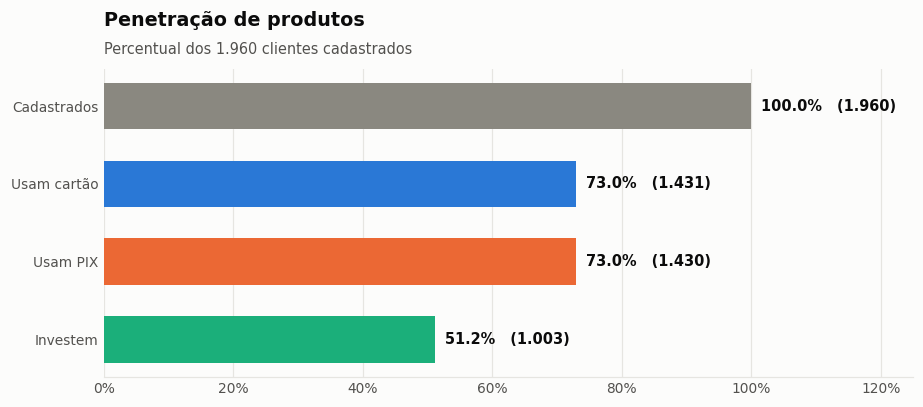

  Clientes sem NENHUMA movimentação em 3 anos: 85  (4.3%)
  Só metade da base investe — e esse número volta a aparecer no notebook 3.


In [3]:
# Quantos dos 1.960 clientes cadastrados usam cada produto?
cobertura = pd.DataFrame({
    'Clientes': [len(clientes), transac.Cliente_ID.nunique(), pix.Cliente_ID.nunique(), invest.Cliente_ID.nunique()],
}, index=['Cadastrados', 'Usam cartão', 'Usam PIX', 'Investem'])
cobertura['% do cadastro'] = (100*cobertura.Clientes/len(clientes)).round(1)

sem_nada = len(set(clientes.Cliente_ID) - set(transac.Cliente_ID) - set(pix.Cliente_ID) - set(invest.Cliente_ID))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.barh(range(4)[::-1], cobertura['% do cadastro'], height=0.6, color=[INK3, BLUE, ORANGE, AQUA])
ax.set_yticks(range(4)[::-1], cobertura.index)
for y, (p, q) in zip(range(4)[::-1], zip(cobertura['% do cadastro'], cobertura.Clientes)):
    ax.text(p + 1.5, y, f'{p:.1f}%   ({n(q)})', va='center', fontsize=9.5, color=INK, fontweight='bold')
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, 125)
ax.xaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'Penetração de produtos', 'Percentual dos 1.960 clientes cadastrados')
plt.tight_layout(); plt.show()

print(f'  Clientes sem NENHUMA movimentação em 3 anos: {sem_nada}  ({100*sem_nada/len(clientes):.1f}%)')
print(f'  Só metade da base investe — e esse número volta a aparecer no notebook 3.')

---
## 2. Quem é o cliente

Perfil demográfico básico, para saber com quem estamos lidando.

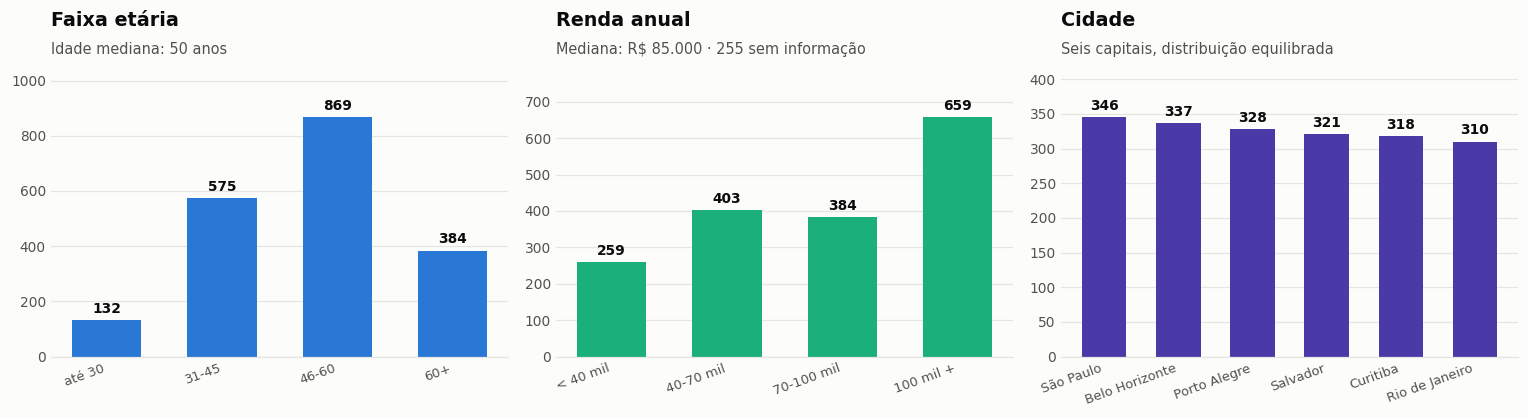

  Cliente típico: 50 anos, renda anual de R$ 85.000, 2 a 3 cartões.
  Atenção: 255 clientes (13%) não têm renda cadastrada. Isso volta no notebook 3.


In [4]:
REF = pd.Timestamp('2025-12-31')
clientes['idade'] = ((REF - clientes.Data_Nascimento).dt.days / 365.25).round(0)
clientes['faixa_etaria'] = pd.cut(clientes.idade, [0, 30, 45, 60, 200], labels=['até 30','31-45','46-60','60+'])
clientes['faixa_renda']  = pd.cut(clientes.Renda_Anual, [0, 40e3, 70e3, 100e3, np.inf],
                                  labels=['< 40 mil','40-70 mil','70-100 mil','100 mil +'])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
for ax, serie, cor, tit, sub in [
        (axes[0], clientes.faixa_etaria.value_counts().reindex(['até 30','31-45','46-60','60+']),
         BLUE,   'Faixa etária',  f'Idade mediana: {clientes.idade.median():.0f} anos'),
        (axes[1], clientes.faixa_renda.value_counts().reindex(['< 40 mil','40-70 mil','70-100 mil','100 mil +']),
         AQUA,   'Renda anual',   f'Mediana: R$ {clientes.Renda_Anual.median():,.0f}'.replace(',', '.') + ' · 255 sem informação'),
        (axes[2], clientes.Cidade.value_counts(),
         VIOLET, 'Cidade',        'Seis capitais, distribuição equilibrada')]:
    ax.bar(range(len(serie)), serie.values, width=0.6, color=cor)
    ax.set_xticks(range(len(serie)), serie.index, rotation=20, ha='right', fontsize=8.5)
    for i, v in enumerate(serie.values):
        ax.text(i, v + serie.max()*0.03, str(v), ha='center', fontsize=9, fontweight='bold', color=INK)
    ax.set_ylim(0, serie.max()*1.20)
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

renda_med = f'{clientes.Renda_Anual.median():,.0f}'.replace(',', '.')
print(f'  Cliente típico: {clientes.idade.median():.0f} anos, renda anual de R$ {renda_med}, 2 a 3 cartões.')
print(f'  Atenção: {clientes.Renda_Anual.isna().sum()} clientes (13%) não têm renda cadastrada. '
      f'Isso volta no notebook 3.')

---
## 3. Onde está a queda

O benchmarking diz que o share caiu. Vamos ver isso aparecer nos dados internos.

A regra que seguimos aqui — e que o notebook 2 vai justificar em detalhe — é usar **contagem de
transações**, não valor em reais. O motivo aparece na seção 4.

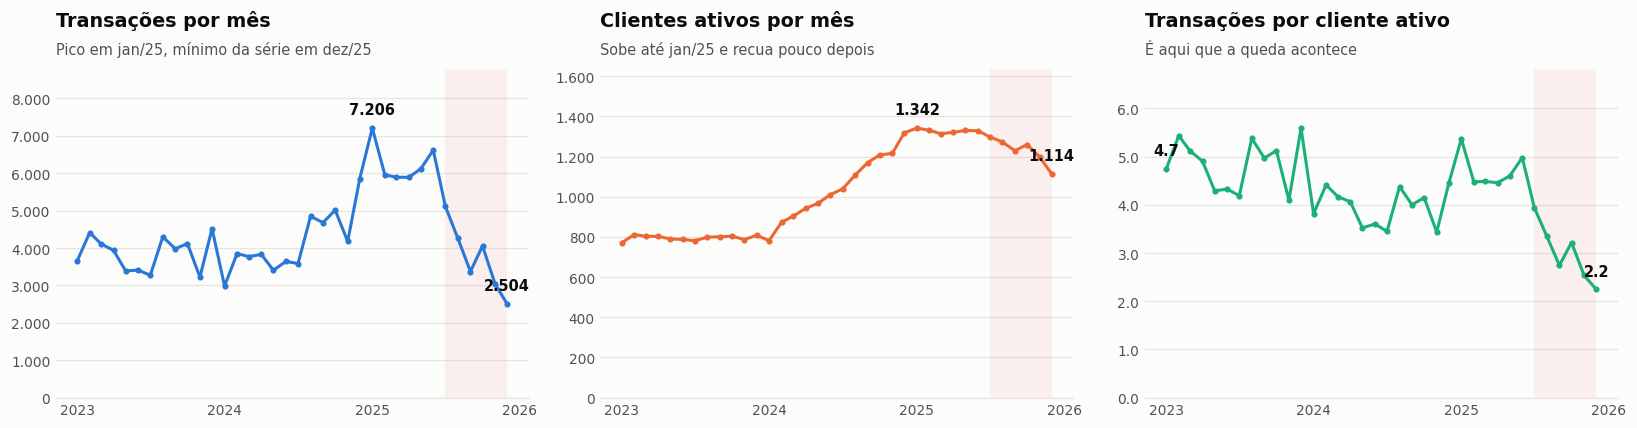

In [5]:
# Só transações que o banco autorizou
aut = transac[transac.Autorizado == 'Sim'].copy()
aut['mes'] = aut.Data.dt.to_period('M')

mensal = aut.groupby('mes').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
mensal['frequencia'] = mensal.transacoes / mensal.clientes

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) 
series = [
    ('transacoes', 'Transações por mês',           BLUE,   FMT_MIL, 'Pico em jan/25, mínimo da série em dez/25'),
    ('clientes',   'Clientes ativos por mês',      ORANGE, FMT_MIL, 'Sobe até jan/25 e recua pouco depois'),
    ('frequencia', 'Transações por cliente ativo', AQUA,   FuncFormatter(lambda v,p: f'{v:.1f}'),
                                                            'É aqui que a queda acontece'),
]
for ax, (col, tit, cor, fmt, sub) in zip(axes, series):
    x, y = mensal.index.to_timestamp(), mensal[col].values
    ax.plot(x, y, color=cor, marker='o', markersize=3)
    ax.axvspan(pd.Timestamp('2025-07-01'), x[-1], color=RED, alpha=0.07, lw=0)
    for i in ([0, len(y)-1] if col == 'frequencia' else [int(np.argmax(y)), len(y)-1]):
        rot = f'{y[i]:.1f}' if col == 'frequencia' else n(y[i])
        ax.annotate(rot, (x[i], y[i]), xytext=(0, 9), textcoords='offset points',
                    ha='center', fontsize=9.5, fontweight='bold', color=INK)
    ax.yaxis.set_major_formatter(fmt); ax.set_ylim(0, max(y)*1.22)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

In [6]:
# A conta que importa: a queda vem de menos clientes ou de menos uso por cliente?
aut['trim'] = aut.Data.dt.to_period('Q')
q = aut.groupby('trim').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
q['frequencia'] = q.transacoes / q.clientes

comp = q.loc[[pd.Period('2025Q1'), pd.Period('2025Q4')]].T
comp.columns = ['1T25', '4T25']
comp['Variação'] = (100*(comp['4T25']/comp['1T25'] - 1)).round(1)
display(comp.style.format({'1T25':'{:,.1f}','4T25':'{:,.1f}','Variação':'{:+.1f}%'}))

print('  A carteira de clientes praticamente não mudou: -3,0%.')
print('  O que desabou foi quanto cada um usa o banco: -48,1%.')
print()
print('  → Isso NÃO é churn. É perda de share-of-wallet.')
print('  → A hipótese fica registrada e será testada formalmente no notebook 3.')

,1T25,4T25,Variação
transacoes,"19,056.0","9,601.0",-49.6%
clientes,"1,403.0","1,361.0",-3.0%
frequencia,13.6,7.1,-48.1%


  A carteira de clientes praticamente não mudou: -3,0%.
  O que desabou foi quanto cada um usa o banco: -48,1%.

  → Isso NÃO é churn. É perda de share-of-wallet.
  → A hipótese fica registrada e será testada formalmente no notebook 3.


### E a outra ponta: a entrada de clientes

Se a base atual usa menos, a pergunta seguinte é se o banco ao menos repõe com clientes novos.

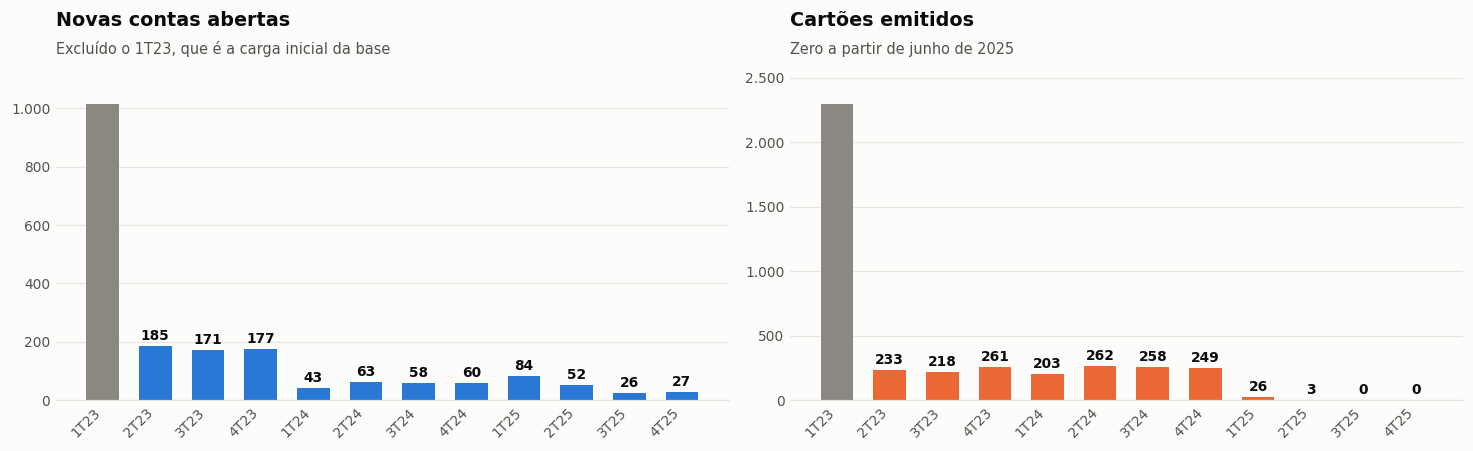

  Novas contas — média por trimestre: 2023 178  ·  2024 56  ·  2025 47
  Cartões emitidos depois de maio de 2025: 0

  → A aquisição caiu 85% e a emissão de cartão parou por completo.
  → Por que ela parou é uma das perguntas do notebook 3.


In [7]:
novas   = clientes.groupby(clientes.Data_Criacao_Conta.dt.to_period('Q')).size()
emissao = cartoes.groupby(cartoes.Data_Emissao.dt.to_period('Q')).size()
idx     = pd.period_range('2023Q1', '2025Q4', freq='Q')
novas, emissao = novas.reindex(idx, fill_value=0), emissao.reindex(idx, fill_value=0)
rot = [f'{p.quarter}T{str(p.year)[2:]}' for p in idx]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax, serie, cor, tit, sub in [
        (axes[0], novas,   BLUE,   'Novas contas abertas',  'Excluído o 1T23, que é a carga inicial da base'),
        (axes[1], emissao, ORANGE, 'Cartões emitidos',      'Zero a partir de junho de 2025')]:
    cores = [INK3 if i == 0 else cor for i in range(len(serie))]
    ax.bar(np.arange(len(serie)), serie.values, width=0.62, color=cores)
    ax.set_xticks(np.arange(len(serie)), rot, rotation=45, ha='right')
    for i, v in enumerate(serie.values):
        if i > 0:
            ax.text(i, v + serie.max()*0.02, str(v), ha='center', fontsize=9, fontweight='bold', color=INK)
    ax.set_ylim(0, serie.max()*1.12); ax.yaxis.set_major_formatter(FMT_MIL)
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

pos = novas[novas.index > pd.Period('2023Q1')]
print(f'  Novas contas — média por trimestre: 2023 {pos[pos.index.year==2023].mean():.0f}  ·  '
      f'2024 {pos[pos.index.year==2024].mean():.0f}  ·  2025 {pos[pos.index.year==2025].mean():.0f}')
print(f'  Cartões emitidos depois de maio de 2025: {int((cartoes.Data_Emissao >= "2025-06-01").sum())}')
print()
print('  → A aquisição caiu 85% e a emissão de cartão parou por completo.')
print('  → Por que ela parou é uma das perguntas do notebook 3.')

---
## 4. Os dados são confiáveis?

Esta seção existe porque **três problemas encontrados aqui mudam o que pode ser afirmado** no resto do
trabalho. Ignorá-los levaria a conclusões erradas com aparência de rigor.

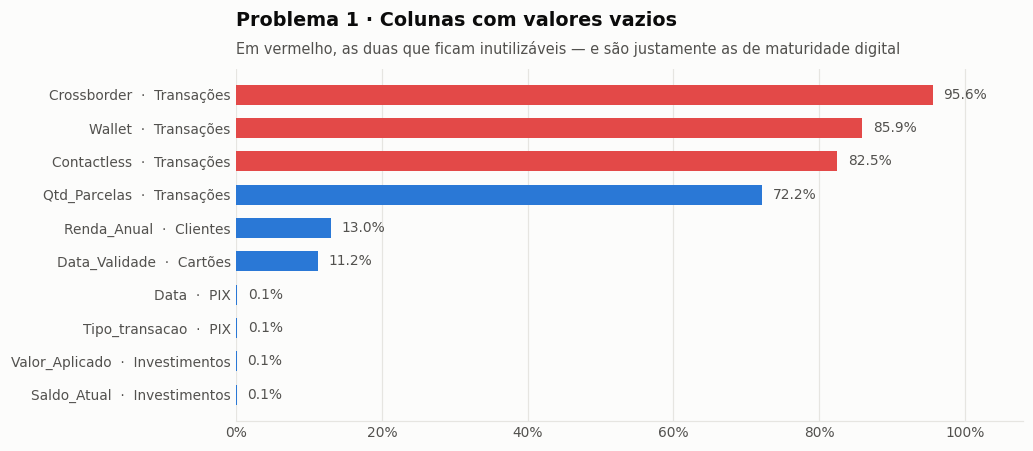

  Nem todo vazio é defeito. "Qtd_Parcelas" e "Wallet" vazios significam alguma coisa —
  o notebook 2 investiga cada um. Mas Crossborder (95,6%) e Contactless (82,5%) são perda real:
  nos poucos preenchidos a divisão é 50/50, ou seja, não há informação para extrair.


In [8]:
# --- Problema 1: colunas vazias demais ---
nulos = []
for nome, df in [('Clientes', clientes), ('Cartões', cartoes), ('Transações', transac),
                 ('PIX', pix), ('Investimentos', invest)]:
    s = df.isna().sum()
    for col, q_ in s[s > 0].items():
        if col in ('idade','faixa_etaria','faixa_renda'): continue
        nulos.append(dict(Base=nome, Coluna=col, Vazios=int(q_), Pct=100*q_/len(df)))
nulos = pd.DataFrame(nulos).sort_values('Pct', ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
y = np.arange(len(nulos))[::-1]
ax.barh(y, nulos.Pct, height=0.6, color=[RED if p > 80 else BLUE for p in nulos.Pct])
ax.set_yticks(y, [f'{r.Coluna}  ·  {r.Base}' for r in nulos.itertuples()], fontsize=9)
for yi, p in zip(y, nulos.Pct):
    ax.text(p + 1.5, yi, f'{p:.1f}%', va='center', fontsize=9, color=INK2)
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(FMT_PCT)
eixo(ax, 'Problema 1 · Colunas com valores vazios',
        'Em vermelho, as duas que ficam inutilizáveis — e são justamente as de maturidade digital')
plt.tight_layout(); plt.show()

print('  Nem todo vazio é defeito. "Qtd_Parcelas" e "Wallet" vazios significam alguma coisa —')
print('  o notebook 2 investiga cada um. Mas Crossborder (95,6%) e Contactless (82,5%) são perda real:')
print('  nos poucos preenchidos a divisão é 50/50, ou seja, não há informação para extrair.')

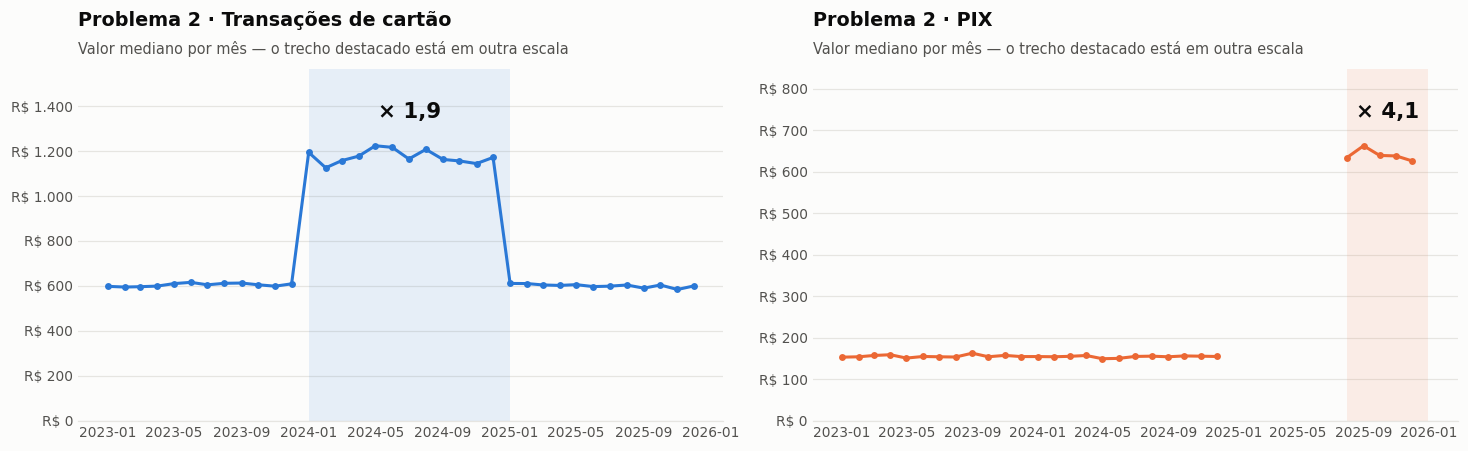

  A distribuição inteira se desloca de um mês para o outro e volta depois. Isso não é
  comportamento de cliente: é como se alguém tivesse trocado a régua no meio da medição.

  Consequência: somar reais entre períodos diferentes produz um crescimento de +156% em 2024
  que nunca existiu. Por isso este notebook usa CONTAGEM, não valor.


In [9]:
# --- Problema 2: o valor em reais muda de escala no meio da série ---
med_tx  = aut[aut.Valor_Compra > 0].groupby('mes').Valor_Compra.median()
pix_ok  = pix[(pix.Aprovado == 1) & (pix.Valor > 0) & pix.Data.notna()].copy()
pix_ok['mes'] = pix_ok.Data.dt.to_period('M')
med_px  = pix_ok.groupby('mes').Valor.median()
todos   = pd.period_range('2023-01', '2025-12', freq='M')
med_tx, med_px = med_tx.reindex(todos), med_px.reindex(todos)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax, s, cor, tit, faixa in [
        (axes[0], med_tx, BLUE,   'Transações de cartão', ('2024-01', '2024-12')),
        (axes[1], med_px, ORANGE, 'PIX',                  ('2025-08', '2025-12'))]:
    x = s.index.to_timestamp()
    ax.plot(x, s.values, color=cor, marker='o', markersize=3.5)
    ini, fim = pd.Timestamp(faixa[0]), pd.Timestamp(faixa[1]) + pd.offsets.MonthEnd(0)
    ax.axvspan(ini, fim, color=cor, alpha=0.10, lw=0)
    dentro = s[(s.index.to_timestamp() >= ini) & (s.index.to_timestamp() <= fim)].median()
    fora   = s[(s.index.to_timestamp() <  ini) | (s.index.to_timestamp() >  fim)].median()
    ax.annotate(f'× {dentro/fora:.1f}'.replace('.', ','), (ini + (fim-ini)/2, np.nanmax(s.values)*1.10),
                ha='center', fontsize=14, fontweight='bold', color=INK)
    ax.set_ylim(0, np.nanmax(s.values)*1.28); ax.yaxis.set_major_formatter(FMT_BRL)
    eixo(ax, f'Problema 2 · {tit}', 'Valor mediano por mês — o trecho destacado está em outra escala')
plt.tight_layout(); plt.show()

print('  A distribuição inteira se desloca de um mês para o outro e volta depois. Isso não é')
print('  comportamento de cliente: é como se alguém tivesse trocado a régua no meio da medição.')
print()
print('  Consequência: somar reais entre períodos diferentes produz um crescimento de +156% em 2024')
print('  que nunca existiu. Por isso este notebook usa CONTAGEM, não valor.')

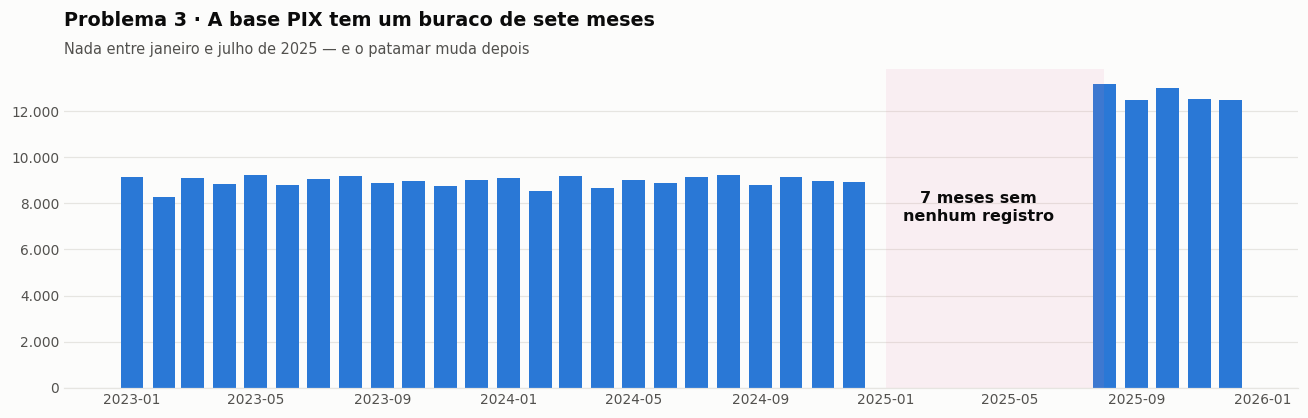

  Meses ausentes: 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07

  Consequência: é impossível distinguir "os clientes pararam de usar PIX" de
  "os dados não foram extraídos". Nenhuma conclusão sobre PIX em 2025 é segura.


In [10]:
# --- Problema 3: sete meses de PIX simplesmente não existem ---
cont = pix.dropna(subset=['Data']).groupby(pix.dropna(subset=['Data']).Data.dt.to_period('M')).size()
cont = cont.reindex(todos, fill_value=0)
falta = cont[cont == 0]

fig, ax = plt.subplots(figsize=(12, 3.9))
x = cont.index.to_timestamp()
ax.bar(x, cont.values, width=22, color=[MAGENTA if v == 0 else BLUE for v in cont.values])
ax.axvspan(falta.index.min().to_timestamp(), falta.index.max().to_timestamp() + pd.offsets.MonthEnd(0),
           color=MAGENTA, alpha=0.10, lw=0)
ax.annotate(f'{len(falta)} meses sem\nnenhum registro',
            (falta.index[len(falta)//2].to_timestamp(), cont.max()*0.55),
            ha='center', fontsize=10.5, fontweight='bold', color=INK)
ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax, 'Problema 3 · A base PIX tem um buraco de sete meses',
        'Nada entre janeiro e julho de 2025 — e o patamar muda depois')
plt.tight_layout(); plt.show()

print(f'  Meses ausentes: {", ".join(str(p) for p in falta.index)}')
print()
print('  Consequência: é impossível distinguir "os clientes pararam de usar PIX" de')
print('  "os dados não foram extraídos". Nenhuma conclusão sobre PIX em 2025 é segura.')

---
## 5. O que aprendemos

**Sobre o negócio**

| Achado | Número |
|---|---|
| A carteira de clientes ficou; o uso é que caiu | clientes -3,0% · frequência **-48,1%** |
| A aquisição de clientes praticamente parou | 178 contas/trimestre em 2023 → **27** no 4T25 |
| A emissão de cartões cessou | **zero** cartões desde junho de 2025 |
| Só metade da base investe | penetração de **51,2%** |

**Sobre os dados** — e isso condiciona todo o resto

1. **Duas quebras de escala** nos valores em reais (transações em 2024, PIX no 2S25). Comparar receita
   entre períodos produziria números falsos.
2. **Sete meses ausentes** na base PIX. Nenhuma tendência de PIX em 2025 é afirmável.
3. **Duas colunas inutilizáveis** (`Crossborder`, `Contactless`) — justamente as que mediriam maturidade
   digital, que é um eixo do benchmarking.

> **Decisão metodológica que atravessa todo o trabalho:** o diagnóstico é construído sobre
> **contagens, frequência e participações**, não sobre valores em reais. Contagem não é afetada por
> troca de escala.

**A hipótese central que sai daqui**

> O Priceless Bank não está perdendo clientes — está perdendo **espaço na carteira** de clientes que
> continuam lá. E parou de repor com clientes novos.

Ela — e mais oito — são testadas formalmente no **notebook 3**. Antes disso, o **notebook 2** trata os
problemas de dados encontrados aqui.